Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

%matplotlib inline

Cell 2: Load Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Cell 3: Dataset Information

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

Cell 4: Check Missing Values

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Cell 5: Data Cleaning

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.dropna(inplace=True)

df["SeniorCitizen"] = df["SeniorCitizen"].replace({1:"Yes",0:"No"})

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Cell 6: Statistical Summary

In [6]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


Cell 7: Churn Distribution

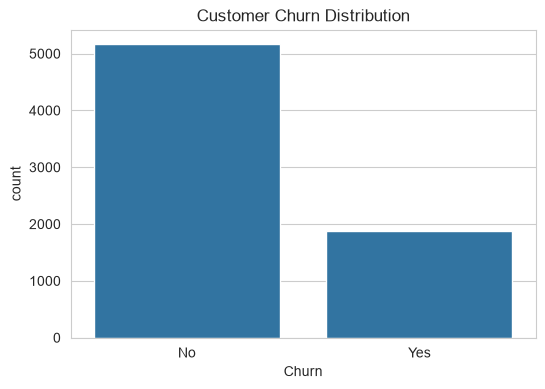

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

Cell 8: Gender vs Churn

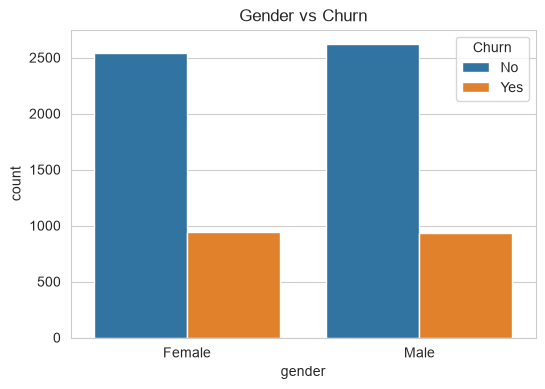

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Churn")

plt.show()

Cell 9: Contract Type vs Churn

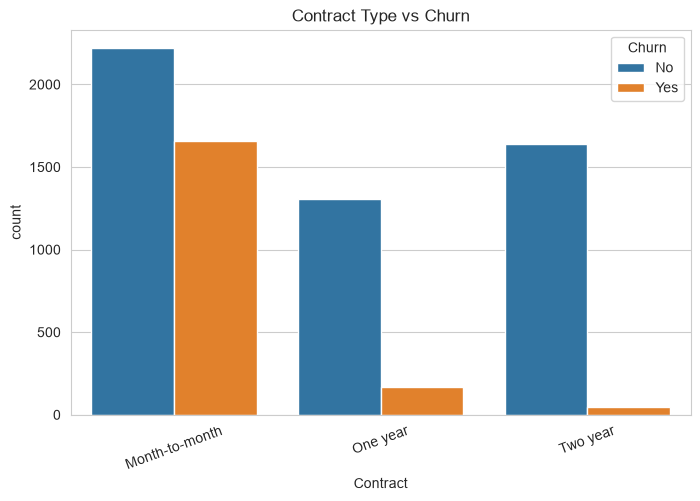

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=20)

plt.show()

Cell 10: Internet Service vs Churn

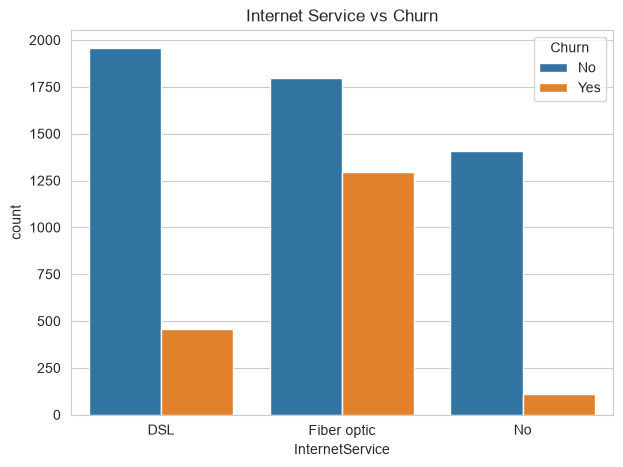

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Churn")

plt.show()

Cell 11: Monthly Charges Distribution

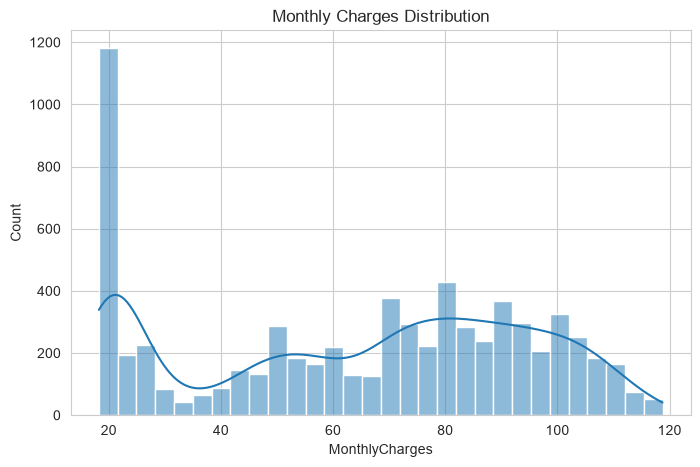

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

Cell 12: Total Charges Distribution

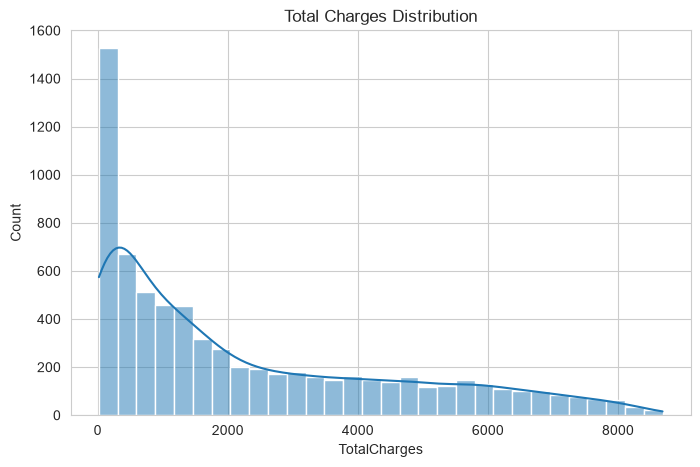

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalCharges"], bins=30, kde=True)

plt.title("Total Charges Distribution")

plt.show()

Cell 13: Tenure Distribution

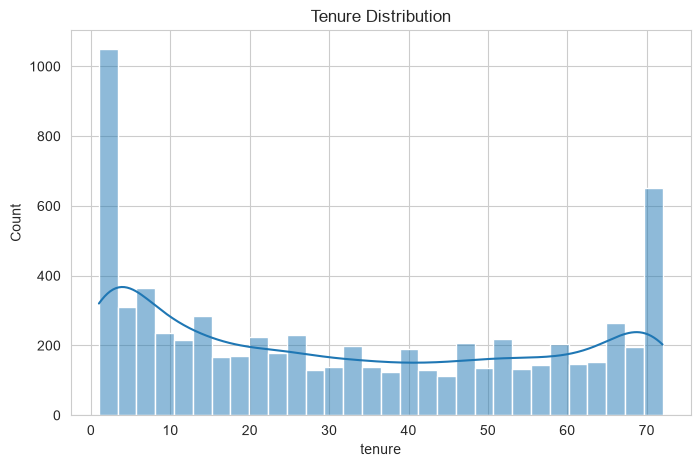

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Tenure Distribution")

plt.show()

Cell 14: Boxplot of Monthly Charges

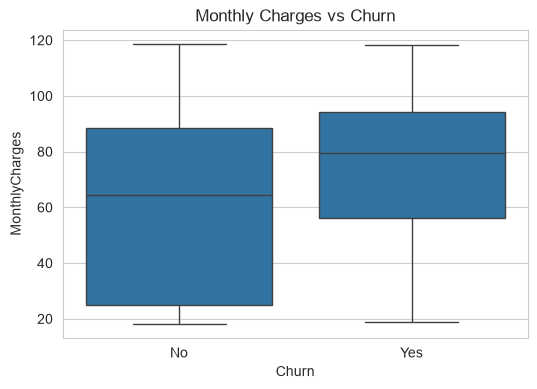

In [14]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

Cell 15: Correlation Heatmap

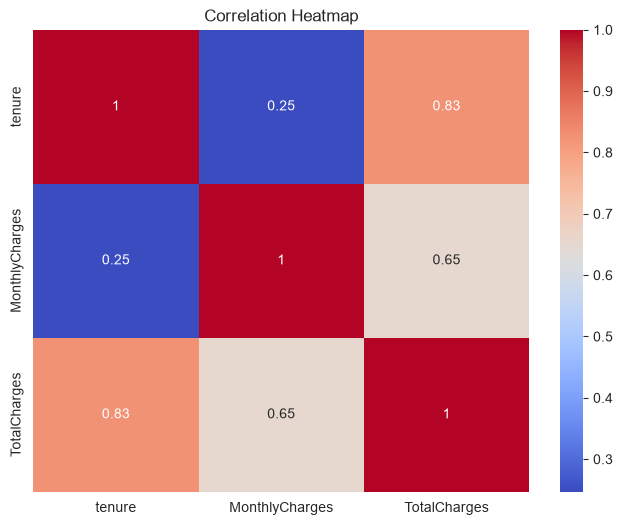

In [15]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

Cell 16: Churn Percentage

In [16]:
churn_percentage = df["Churn"].value_counts(normalize=True)*100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Cell 17: Monthly Charges by Contract

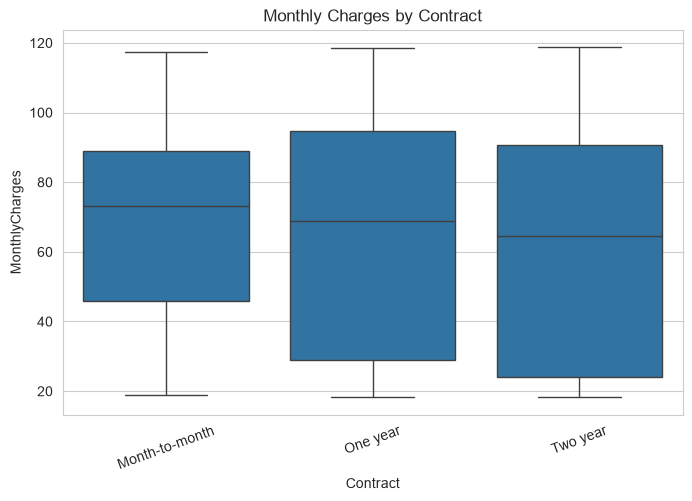

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Contract", y="MonthlyCharges", data=df)

plt.title("Monthly Charges by Contract")

plt.xticks(rotation=20)

plt.show()

Cell 18: Senior Citizen vs Churn

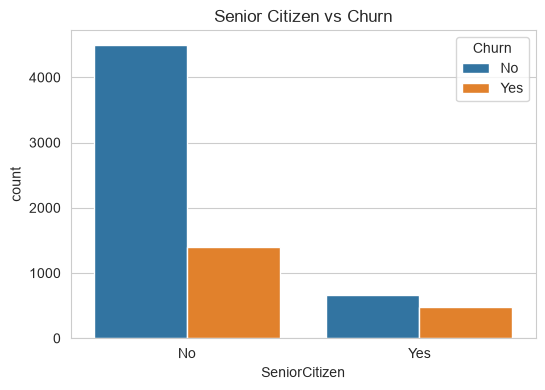

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Churn")

plt.show()

Cell 19: Payment Method vs Churn

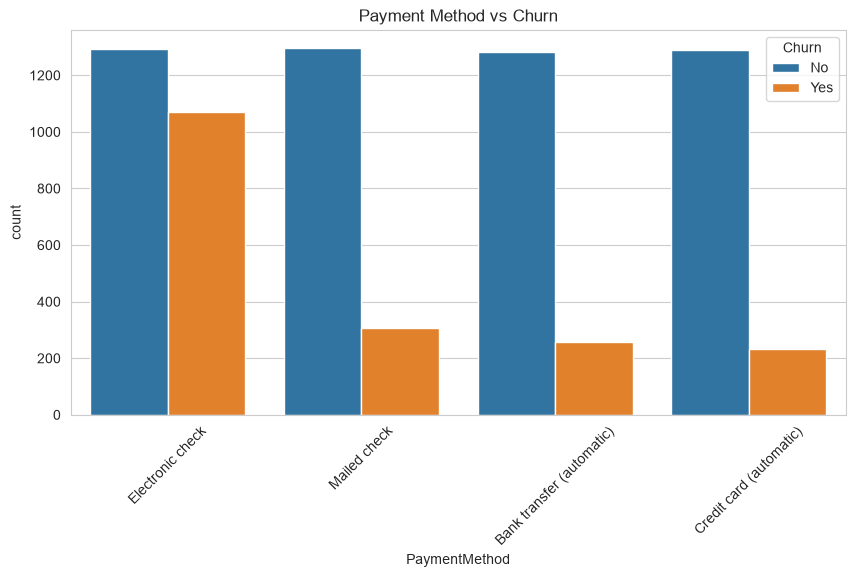

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.show()

Cell 20: Conclusion

In [21]:
print("""
EDA Conclusion

1. Customers with Month-to-Month contracts have the highest churn.
2. Fiber Optic users churn more frequently.
3. Customers with higher monthly charges tend to churn more.
4. Longer-tenure customers are less likely to churn.
5. Electronic Check payment users show higher churn rates.
6. Senior citizens have a relatively higher churn rate.
""")


EDA Conclusion

1. Customers with Month-to-Month contracts have the highest churn.
2. Fiber Optic users churn more frequently.
3. Customers with higher monthly charges tend to churn more.
4. Longer-tenure customers are less likely to churn.
5. Electronic Check payment users show higher churn rates.
6. Senior citizens have a relatively higher churn rate.

